<a href="https://colab.research.google.com/github/Annrosejojue/Industrial-Failure-Predictor/blob/main/Industrial_Failure_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install xgboost shap lime -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:

import pandas as pd

df = pd.read_csv("/content/ai4i2020.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nInfo:")
print(df.info())
print("\nClass balance (Machine failure):")
print(df["Machine failure"].value_counts(normalize=True))

df.describe()


Shape: (10000, 14)

Columns:
 Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF         

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


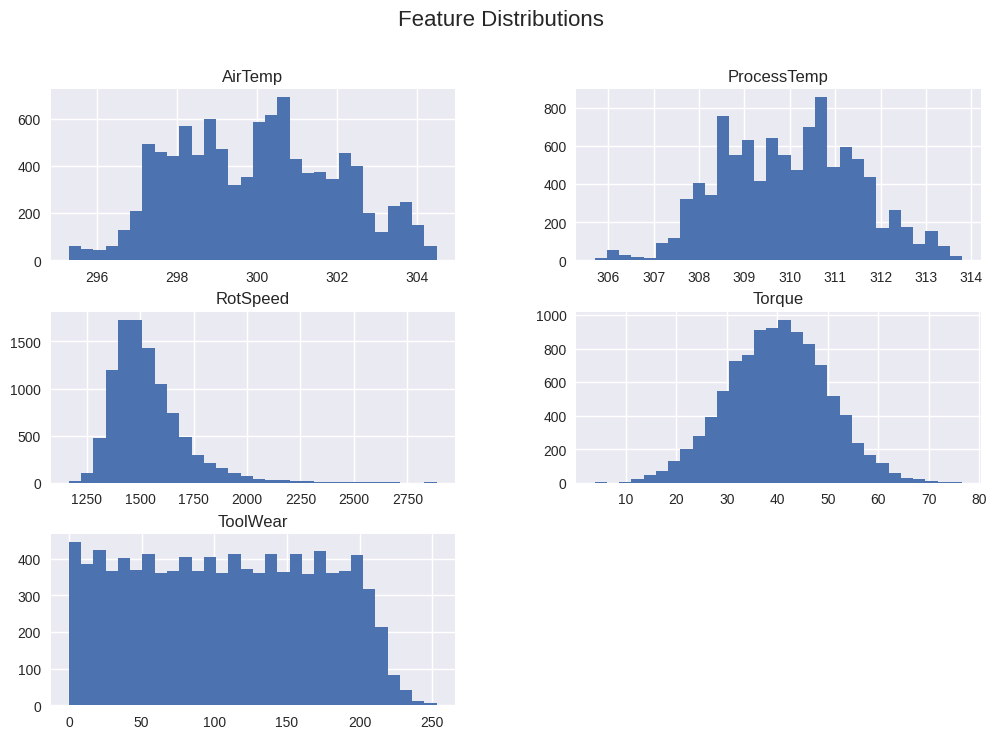

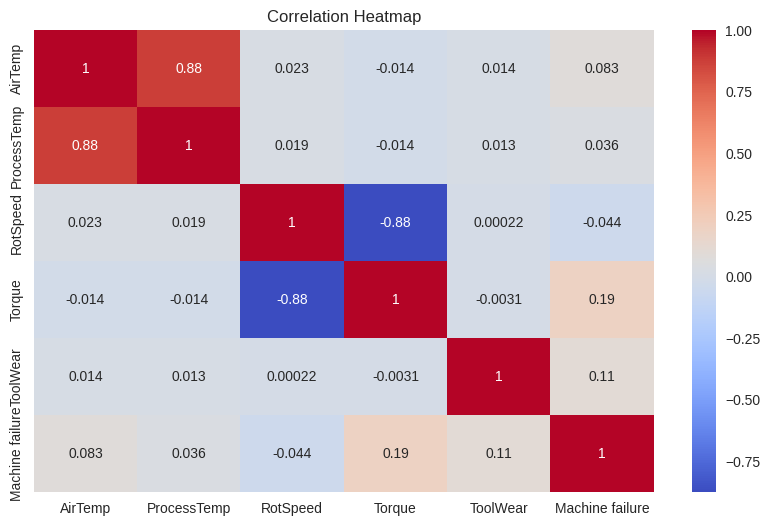

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df.rename(columns={
    "Air temperature [K]": "AirTemp",
    "Process temperature [K]": "ProcessTemp",
    "Rotational speed [rpm]": "RotSpeed",
    "Torque [Nm]": "Torque",
    "Tool wear [min]": "ToolWear",
})

df.isna().sum()

num_cols = ["AirTemp", "ProcessTemp", "RotSpeed", "Torque", "ToolWear"]
df[num_cols].hist(bins=30, figsize=(12, 8))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols + ["Machine failure"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [6]:
df["TempDiff"] = df["ProcessTemp"] - df["AirTemp"]

df = pd.get_dummies(df, columns=["Type"], drop_first=True)

df = df.drop(columns=["UDI", "Product ID"])

X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

print("Final features:", X.columns)


Final features: Index(['AirTemp', 'ProcessTemp', 'RotSpeed', 'Torque', 'ToolWear', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF', 'TempDiff', 'Type_L', 'Type_M'],
      dtype='object')


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



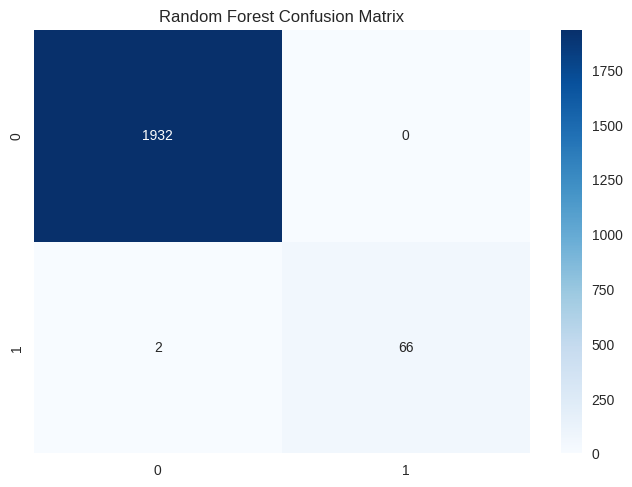

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()


=== XGBoost Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



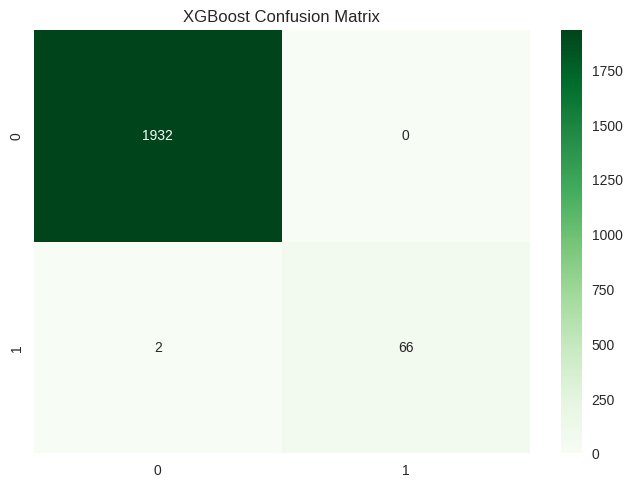

In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("=== XGBoost Report ===")
print(classification_report(y_test, y_pred_xgb))

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt="d", cmap="Greens")
plt.title("XGBoost Confusion Matrix")
plt.show()


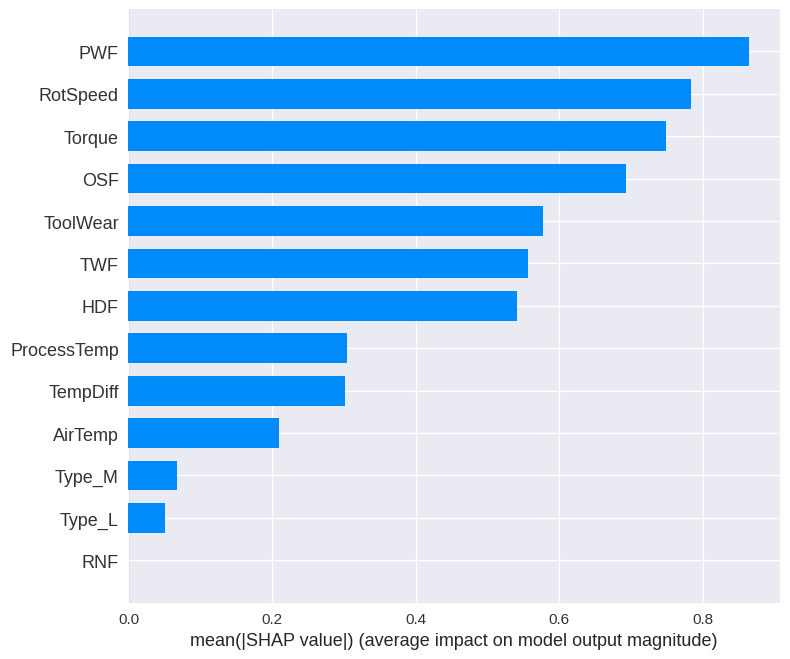

In [10]:
shap.initjs()

sample_idx = np.random.choice(X_train.shape[0], size=800, replace=False)
X_sample = X_train.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, plot_type="bar")


In [11]:
explainer_lime = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=X.columns,
    class_names=["No Failure", "Failure"],
    discretize_continuous=True,
    mode="classification"
)

i = 0
exp = explainer_lime.explain_instance(
    X_test_scaled[i],
    xgb.predict_proba,
    num_features=10
)

exp.show_in_notebook(show_table=True)


In [12]:
df["Torque_MA5"] = df["Torque"].rolling(5).mean()
df["RotSpeed_STD5"] = df["RotSpeed"].rolling(5).std()


In [13]:
df["Torque_x_Wear"] = df["Torque"] * df["ToolWear"]
df["Temp_Ratio"] = df["ProcessTemp"] / df["AirTemp"]


In [14]:
df["Wear_Squared"] = df["ToolWear"]**2


In [15]:
from sklearn.metrics import f1_score


In [16]:
!pip install optuna -q
import optuna

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }
    model = XGBClassifier(**params, eval_metric="logloss")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
study.best_params


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.9 MB/s eta 0:00:00


[I 2026-02-04 18:17:48,282] A new study created in memory with name: no-name-6de935cf-2222-41d5-8aaa-b162e0bde9ab
[I 2026-02-04 18:17:52,595] Trial 0 finished with value: 0.9696969696969697 and parameters: {'n_estimators': 196, 'max_depth': 10, 'learning_rate': 0.012531189995803042, 'subsample': 0.7801165110692522, 'colsample_bytree': 0.7775043729607306}. Best is trial 0 with value: 0.9696969696969697.
[I 2026-02-04 18:17:55,999] Trial 1 finished with value: 0.9850746268656716 and parameters: {'n_estimators': 487, 'max_depth': 10, 'learning_rate': 0.03378224904916094, 'subsample': 0.9263376026977868, 'colsample_bytree': 0.609897171564072}. Best is trial 1 with value: 0.9850746268656716.
[I 2026-02-04 18:17:56,889] Trial 2 finished with value: 0.9701492537313433 and parameters: {'n_estimators': 161, 'max_depth': 10, 'learning_rate': 0.16664506297394802, 'subsample': 0.712504027282286, 'colsample_bytree': 0.6995138959539212}. Best is trial 1 with value: 0.9850746268656716.
[I 2026-02-04 

{'n_estimators': 487,
 'max_depth': 10,
 'learning_rate': 0.03378224904916094,
 'subsample': 0.9263376026977868,
 'colsample_bytree': 0.609897171564072}

In [17]:
from imblearn.over_sampling import SMOTE
sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train, y_train)


In [18]:
xgb = XGBClassifier(scale_pos_weight=5)


In [19]:
!pip install catboost -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.5 MB/s eta 0:00:00


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [21]:
models = {
    "LogReg": LogisticRegression(),
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier(),
    "LGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = f1_score(y_test, preds)

results


[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1017
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


{'LogReg': 0.8760330578512396,
 'RF': 0.9850746268656716,
 'XGB': 0.9850746268656716,
 'LGBM': 0.9850746268656716,
 'CatBoost': 0.9850746268656716}

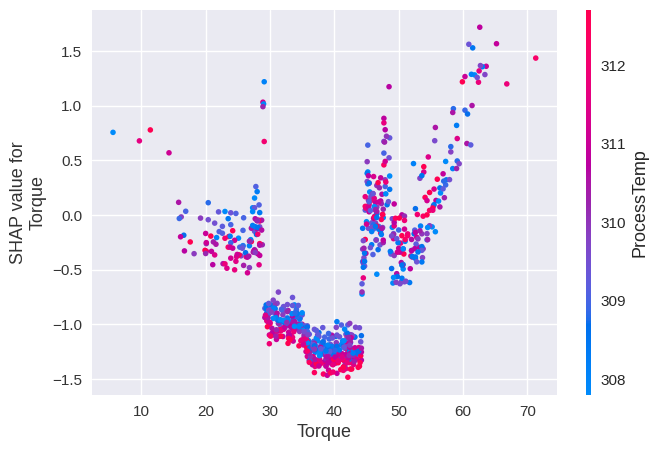

In [22]:
shap.dependence_plot("Torque", shap_values, X_sample)

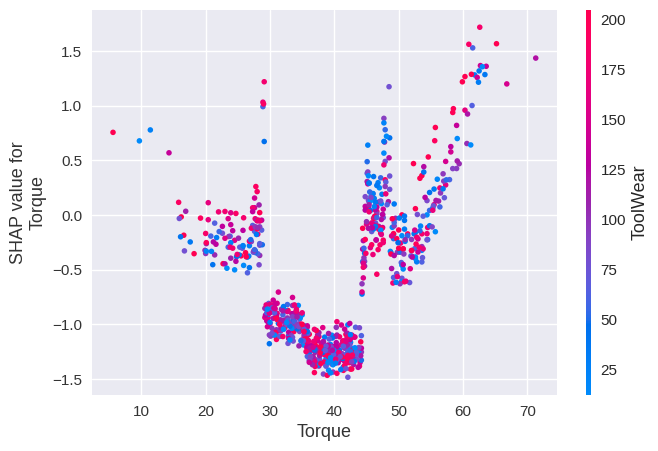

In [23]:
shap.dependence_plot("Torque", shap_values, X_sample, interaction_index="ToolWear")

In [24]:
df = df.rename(columns={"Torque_MAS": "Torque_MA5"})


In [25]:
df["Torque_MA5"] = df["Torque"].rolling(5).mean()
df["RotSpeed_STD5"] = df["RotSpeed"].rolling(5).std()


In [26]:
df = df.fillna(method="bfill")


In [27]:
df.columns


Index(['AirTemp', 'ProcessTemp', 'RotSpeed', 'Torque', 'ToolWear',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'TempDiff',
       'Type_L', 'Type_M', 'Torque_MA5', 'RotSpeed_STD5', 'Torque_x_Wear',
       'Temp_Ratio', 'Wear_Squared'],
      dtype='object')

In [30]:
!pip install dice-ml --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.0 MB/s eta 0:00:00


In [73]:
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna()


In [74]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]


In [81]:
df_scaled.dtypes


,0
AirTemp,float64
ProcessTemp,float64
RotSpeed,float64
Torque,float64
ToolWear,float64
TWF,float64
HDF,float64
PWF,float64
OSF,float64
RNF,float64


In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [77]:
xgb.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [98]:
df = df.apply(pd.to_numeric, errors="coerce")
df = df.dropna()


In [99]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [102]:
xgb.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [103]:
df_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
df_scaled["Machine failure"] = y_train.values


In [106]:
exp.data_interface.data_df.dtypes


,0
AirTemp,float32
ProcessTemp,float32
RotSpeed,float32
Torque,float32
ToolWear,float32
TWF,category
HDF,category
PWF,category
OSF,category
RNF,category
